# Kapitel 2 - Koduppgift 12
##### Har gjort som boken man kan ändra hyoerparamtrarna för att få bättre resultat. men varje test tar lång tid. Förbättringen ligger seprat i Kunskapskontrollen_kapitel_2_Koduppgift_12_median.ipynb

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib

import seaborn as sns	
import time

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split 
from sklearn.metrics import root_mean_squared_error 
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import GridSearchCV	


housing_original = pd.read_csv("housing.csv")

housing_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
housing_original.iloc[:, :6].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population
0,-122.23,37.88,41.0,880.0,129.0,322.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0


In [4]:
housing_original.iloc[:, 5:].head()

,population,households,median_income,median_house_value,ocean_proximity
0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,496.0,177.0,7.2574,352100.0,NEAR BAY
3,558.0,219.0,5.6431,341300.0,NEAR BAY
4,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing_original['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
housing = housing_original[housing_original['ocean_proximity'] != 'ISLAND']
housing['ocean_proximity'].value_counts() 


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
Name: count, dtype: int64

In [7]:
housing = pd.get_dummies(housing, columns = ['ocean_proximity'], dtype = int, prefix = 'dmy')

In [8]:
housing.iloc[[1, 200, 1000, 1850, 5000], 9:]

,dmy_<1H OCEAN,dmy_INLAND,dmy_NEAR BAY,dmy_NEAR OCEAN
1,0,0,1,0
200,0,0,1,0
1000,0,1,0,0
1850,0,0,0,1
5000,1,0,0,0


In [9]:
train_full, test = train_test_split(housing, test_size=0.2, random_state=40) 
train, val = train_test_split(train_full, test_size=0.25,  random_state=36)


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12381 entries, 12054 to 14298
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           12381 non-null  float64
 1   latitude            12381 non-null  float64
 2   housing_median_age  12381 non-null  float64
 3   total_rooms         12381 non-null  float64
 4   total_bedrooms      12261 non-null  float64
 5   population          12381 non-null  float64
 6   households          12381 non-null  float64
 7   median_income       12381 non-null  float64
 8   median_house_value  12381 non-null  float64
 9   dmy_<1H OCEAN       12381 non-null  int64  
 10  dmy_INLAND          12381 non-null  int64  
 11  dmy_NEAR BAY        12381 non-null  int64  
 12  dmy_NEAR OCEAN      12381 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 1.3 MB


In [11]:
train = train.dropna()
train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 12261 entries, 12054 to 14298
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           12261 non-null  float64
 1   latitude            12261 non-null  float64
 2   housing_median_age  12261 non-null  float64
 3   total_rooms         12261 non-null  float64
 4   total_bedrooms      12261 non-null  float64
 5   population          12261 non-null  float64
 6   households          12261 non-null  float64
 7   median_income       12261 non-null  float64
 8   median_house_value  12261 non-null  float64
 9   dmy_<1H OCEAN       12261 non-null  int64  
 10  dmy_INLAND          12261 non-null  int64  
 11  dmy_NEAR BAY        12261 non-null  int64  
 12  dmy_NEAR OCEAN      12261 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 1.3 MB


In [12]:
val = val.dropna() 
test = test.dropna()

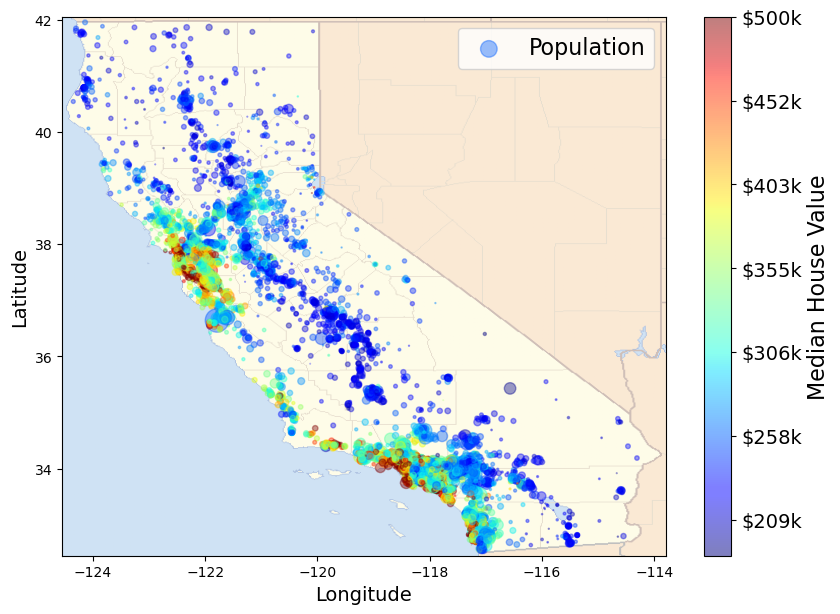

In [13]:
import matplotlib.image as mpimg

california_img=mpimg.imread('california.png') 

ax = train.plot(kind="scatter", x="longitude", y="latitude",
    figsize=(10,7), s=train['population']/100, label="Population", c="median_house_value",
    cmap=plt.get_cmap("jet"), colorbar=False, alpha=0.4)

plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5, cmap=plt.get_cmap("jet"))

plt.ylabel("Latitude", fontsize=14) 

plt.xlabel("Longitude", fontsize=14)

prices = train["median_house_value"]

tick_values = np.linspace(prices.min(), prices.max(), 11)	

cbar = plt.colorbar(ticks=tick_values/prices.max()) 

cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in
    tick_values], fontsize=14) 
cbar.set_label('Median House Value', fontsize=16) 

plt.legend(fontsize=16)	


In [14]:
corr_matrix = train.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.689648
dmy_<1H OCEAN         0.253893
dmy_NEAR BAY          0.159601
dmy_NEAR OCEAN        0.148101
total_rooms           0.132945
housing_median_age    0.099810
households            0.063797
total_bedrooms        0.048099
population           -0.025675
longitude            -0.043444
latitude             -0.147407
dmy_INLAND           -0.485680
Name: median_house_value, dtype: float64

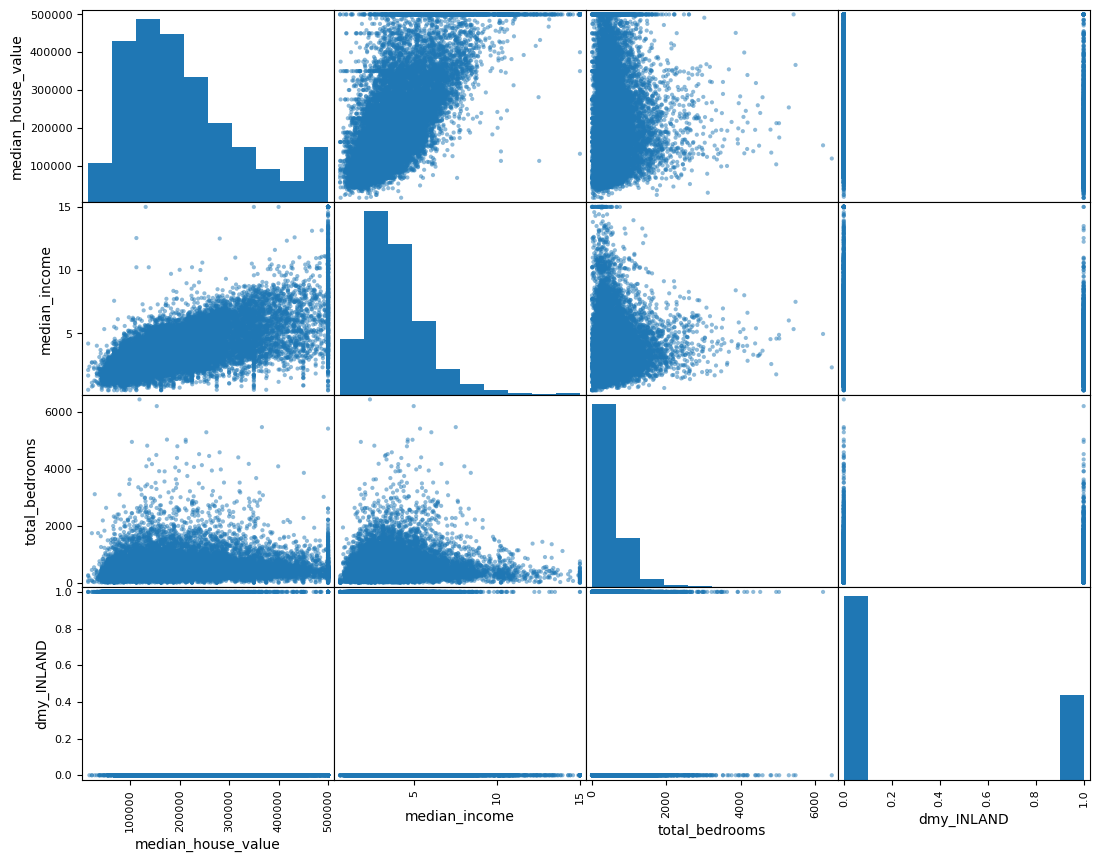

In [15]:
attributes = ["median_house_value", "median_income", "total_bedrooms", "dmy_INLAND"]
pd.plotting.scatter_matrix(housing[attributes], figsize=(13, 10))
plt.show()

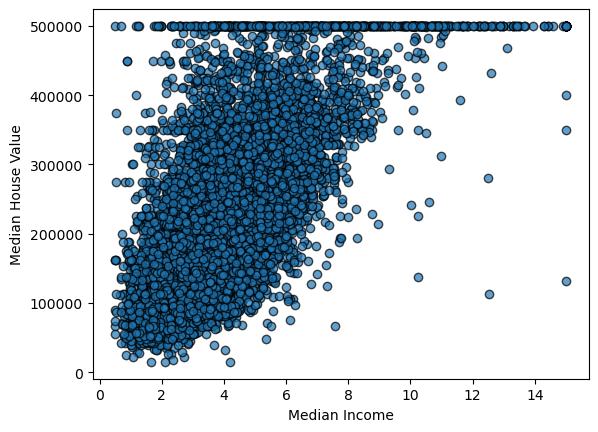

In [16]:
plt.scatter(train['median_income'], train['median_house_value'], alpha=0.7, edgecolor='k')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()


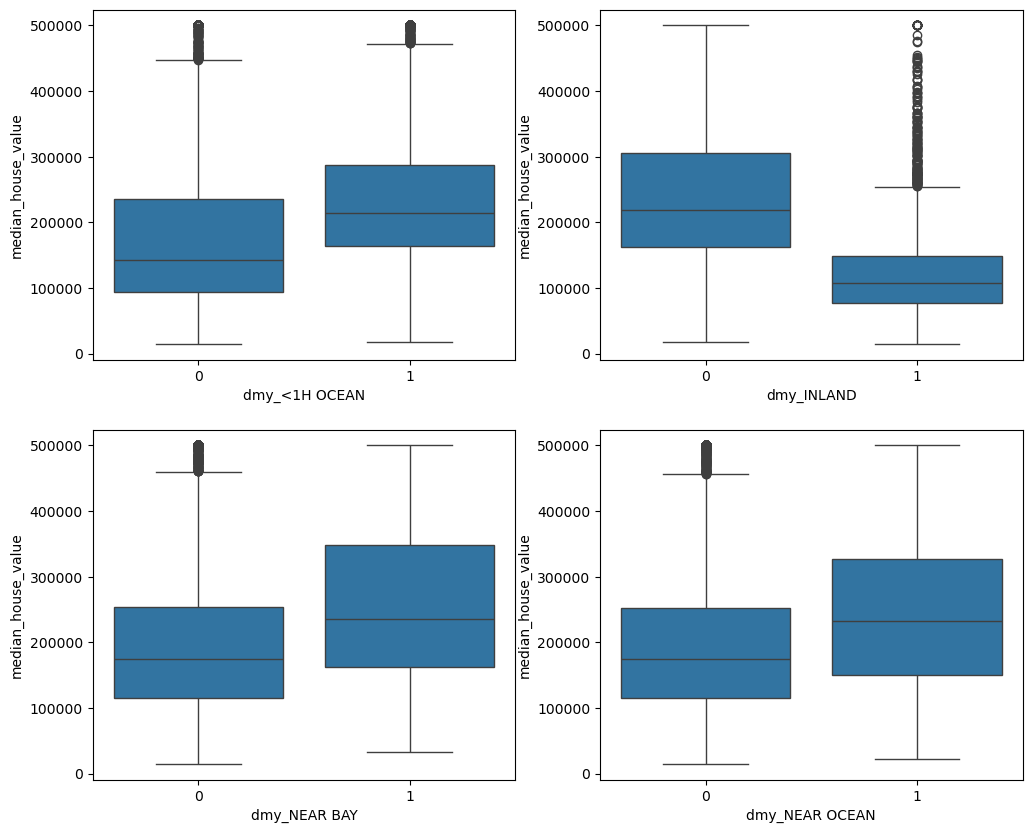

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(data=train, x='dmy_<1H OCEAN', y='median_house_value', ax=axes[0, 0])
sns.boxplot(data=train, x='dmy_INLAND', y='median_house_value', ax=axes[0, 1])
sns.boxplot(data=train, x='dmy_NEAR BAY', y='median_house_value', ax=axes[1, 0])
sns.boxplot(data=train, x='dmy_NEAR OCEAN', y='median_house_value', ax=axes[1, 1])
plt.show()

In [18]:
X_train_full = train_full.drop(columns=['median_house_value'])
y_train_full = train_full['median_house_value']
X_train, y_train = train.drop(columns=['median_house_value']), train['median_house_value']
X_val, y_val = val.drop(columns=['median_house_value']), val['median_house_value']
X_test, y_test = test.drop(columns=['median_house_value']), test['median_house_value']

In [19]:
print(X_train.shape)
print(y_train.shape)

(12261, 12)
(12261,)


In [20]:

from sklearn.linear_model import LinearRegression 
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [21]:
start_time = time.time()

rf = RandomForestRegressor()

hyperparam_grid = {'max_depth': [20, 30, 40, 50], 'n_estimators':
    [50, 100, 150]}

grid_search = GridSearchCV(rf, hyperparam_grid,
    scoring='neg_root_mean_squared_error', cv=5) 

grid_search.fit(X_train, y_train) 

end_time = time.time()

execution_time = end_time - start_time

print(f"GridSearchCV fitting took {execution_time:.4f} seconds.")


GridSearchCV fitting took 635.7230 seconds.


In [22]:
print("Best Hyperparameters from GridSearchCV:",  
      grid_search.best_params_)

Best Hyperparameters from GridSearchCV: {'max_depth': 20, 'n_estimators': 150}


In [23]:
lr_pred_val = lin_reg.predict(X_val)	

rf_pred_val = grid_search.predict(X_val)	

print('RMSE Linear Regression:', root_mean_squared_error(y_val, lr_pred_val))	

print('RMSE Random Forest Regression:',
    root_mean_squared_error(y_val, rf_pred_val))	



RMSE Linear Regression: 69442.09533293538
RMSE Random Forest Regression: 49492.66050864069


In [24]:
print(np.mean(y_val)) 
print(root_mean_squared_error(y_val, rf_pred_val)/np.mean(y_val))

207517.1138589618
0.2384991752645432


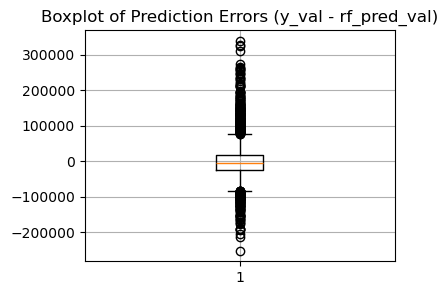

In [25]:
errors = y_val - rf_pred_val
plt.figure(figsize=(4, 3)) 
plt.boxplot(errors)
plt.title('Boxplot of Prediction Errors (y_val - rf_pred_val)') 
plt.grid(True)


In [26]:
best_params = grid_search.best_params_ 
best_params

{'max_depth': 20, 'n_estimators': 150}

In [27]:
best_rf = RandomForestRegressor(**best_params)	

best_rf.fit(X_train_full, y_train_full)	



RandomForestRegressor(max_depth=20, n_estimators=150)

In [28]:
best_rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 20,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 150,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [29]:

rf_pred_test = best_rf.predict(X_test)
rmse_test = root_mean_squared_error(y_test, rf_pred_test) 
print('RMSE Random Forest on Test data:', rmse_test) 
print(rmse_test/np.mean(y_test))


RMSE Random Forest on Test data: 48406.44479714799
0.23412515603284087


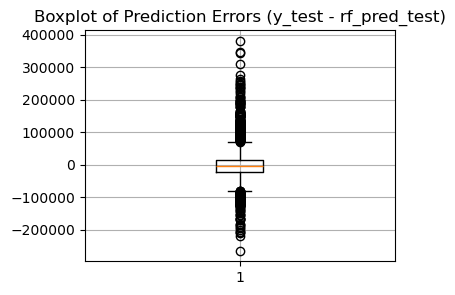

In [30]:
errors = y_test - rf_pred_test
plt.figure(figsize=(4, 3)) 
plt.boxplot(errors)
plt.title('Boxplot of Prediction Errors (y_test - rf_pred_test)') 
plt.grid(True)


In [31]:
X_full = housing.drop(columns=['median_house_value']) 
y_full = housing['median_house_value']
saved_model = RandomForestRegressor(**best_params) 
saved_model.fit(X_full, y_full) 
joblib.dump(saved_model, 'rf_saved_model.pkl')


['rf_saved_model.pkl']

In [32]:
new_districts = pd.DataFrame({
'longitude': [-118.30, -117.85],
'latitude': [34.20, 33.90],
'housing_median_age': [35.0, 20.0],
'total_rooms': [880.0, 1200.0],
'total_bedrooms': [200.0, 300.0],
'population': [500.0, 750.0],
'households': [220.0, 280.0],
'median_income': [4.2, 5.1],
'dmy_<1H OCEAN': [0, 1],
'dmy_INLAND': [1, 0],
'dmy_NEAR BAY': [0, 0],
'dmy_NEAR OCEAN': [0, 0] })		

predicted_values = saved_model.predict(new_districts)		

for i, value in enumerate(predicted_values, start=1):
    print(f"Predicted median house value for district {i}: ${value:,.2f}")

Predicted median house value for district 1: $222,586.59
Predicted median house value for district 2: $198,451.56
